# Customer Intelligence / Country Segmentation Notebook

## Unsupervised Learning on Country Data

This notebook helps interns learn a full clustering workflow using the Kaggle dataset **Unsupervised Learning on Country Data**.

### Goals
- Load and inspect the data
- Clean and preprocess features
- Apply scaling
- Find the best number of clusters with K-Means
- Try DBSCAN as a second clustering method
- Visualize clusters with PCA
- Create simple country-level insights


# Week 3 Assignment: Customer Intelligence System
**Dataset:** Unsupervised Learning on Country Data
**Name:** Tejender Singh
**Techniques:** EDA, Scaling, PCA, K-Means, DBSCAN, Random Forest, XGBoost

## 2) Import libraries

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, accuracy_score, classification_report
from xgboost import XGBClassifier

print("Libraries loaded!")

Libraries loaded!


## 3) Load the dataset

Upload the CSV file from Kaggle when prompted.


In [67]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


In [68]:
df = pd.read_csv("/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv")

print(f"✅ Data Loaded! Shape: {df.shape}")
df.head(10)

✅ Data Loaded! Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


## 5) Expected columns

This dataset is commonly used for country clustering and usually contains:
- country
- child_mort
- exports
- health
- imports
- income
- inflation
- life_expec
- total_fer
- gdpp


In [69]:
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


## 6) Basic cleaning

Handle missing values, remove duplicates, and make sure numeric columns are clean.

In [70]:
# Check data types and missing values
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None

Missing values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [71]:
# Basic statistics of all columns
df.describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


## 7) Exploratory Data Analysis

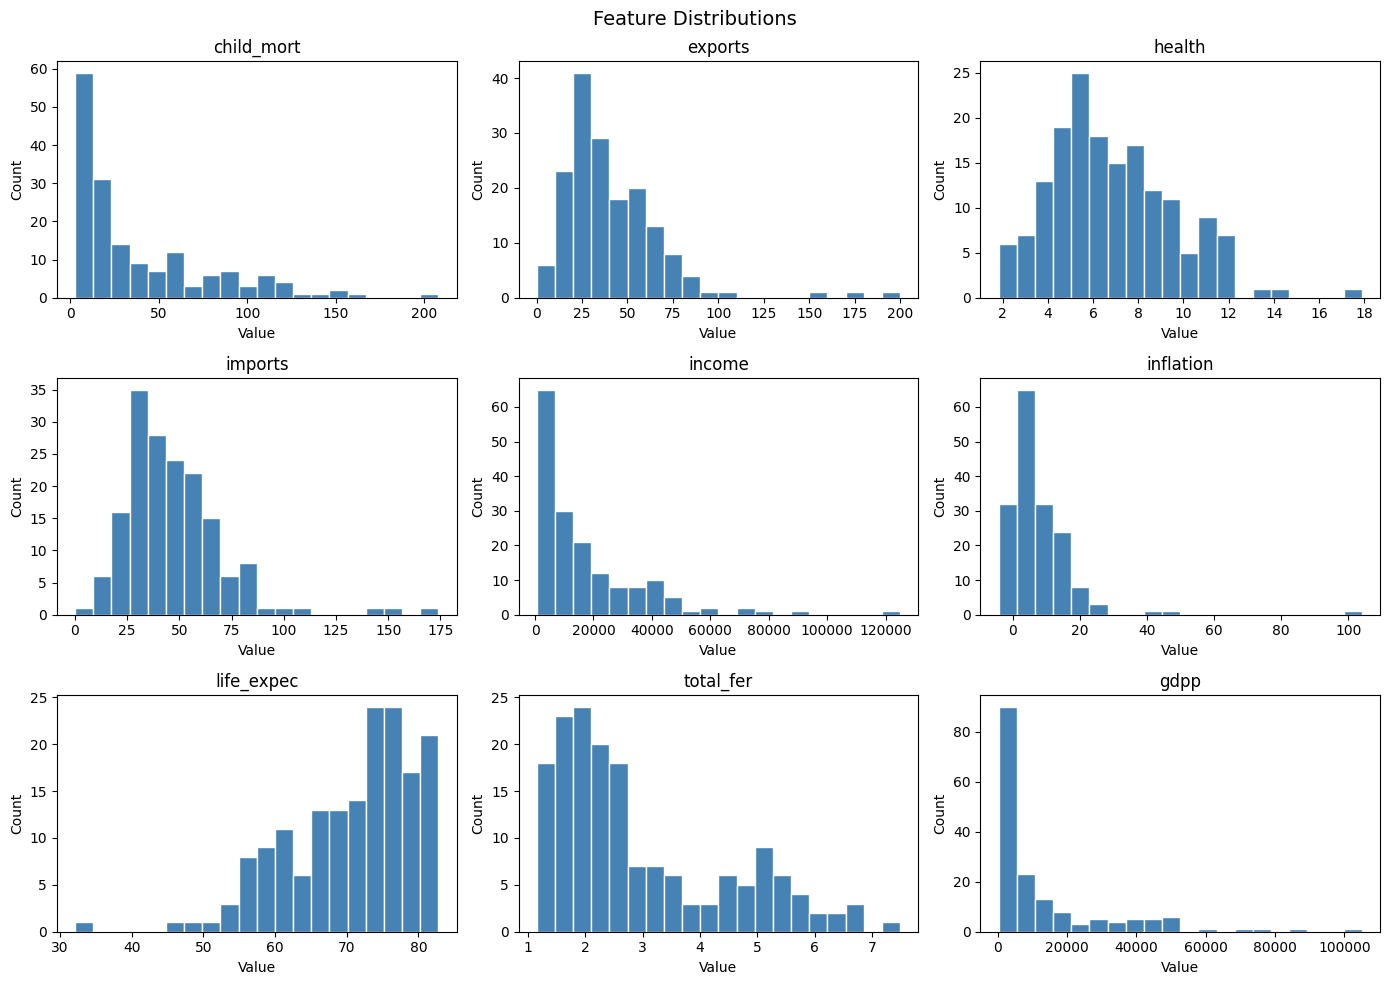

In [72]:
# Plot distribution of each feature
features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for i, col in enumerate(features):
    ax = axes[i//3][i%3]
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

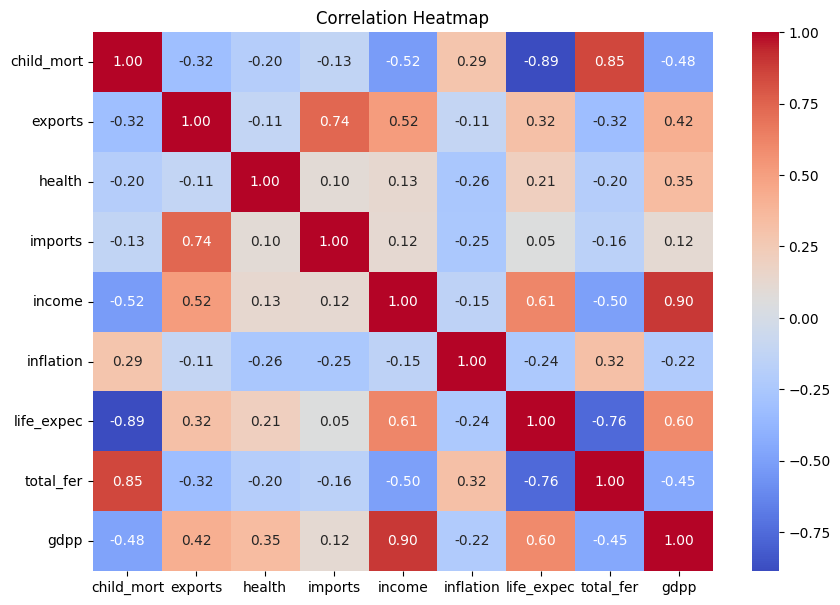

In [73]:
# Check which features are related to each other
plt.figure(figsize=(10, 7))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [74]:
# Countries with highest child mortality
print("Top 10 countries by child mortality:")
print(df.nlargest(10, 'child_mort')[['country', 'child_mort']])

Top 10 countries by child mortality:
                      country  child_mort
66                      Haiti       208.0
132              Sierra Leone       160.0
32                       Chad       150.0
31   Central African Republic       149.0
97                       Mali       137.0
113                   Nigeria       130.0
112                     Niger       123.0
3                      Angola       119.0
25               Burkina Faso       116.0
37           Congo, Dem. Rep.       116.0


# 8) Data Preprocessing

In [75]:
# Remove country name column before scaling
X = df.drop('country', axis=1)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling done!")
print("Shape after scaling:", X_scaled.shape)

Scaling done!
Shape after scaling: (167, 9)


# 9) PCA Visualization

In [76]:
# Reduce dimensions while keeping 95% information
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original features:", X_scaled.shape[1])
print("After PCA:", X_pca.shape[1])
print("Variance kept:", round(sum(pca.explained_variance_ratio_) * 100, 2), "%")

Original features: 9
After PCA: 6
Variance kept: 97.02 %


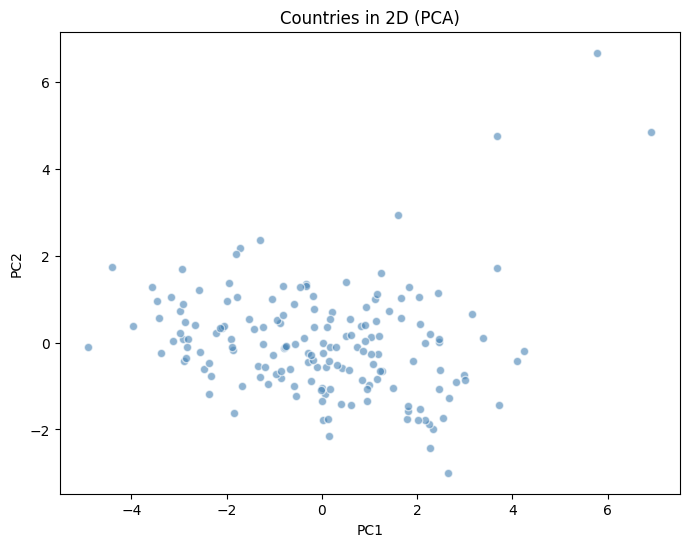

In [77]:
# Visualize countries in 2D using PCA
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], color='steelblue', alpha=0.6, edgecolors='white')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Countries in 2D (PCA)')
plt.show()

# 10) K-Means Clustering

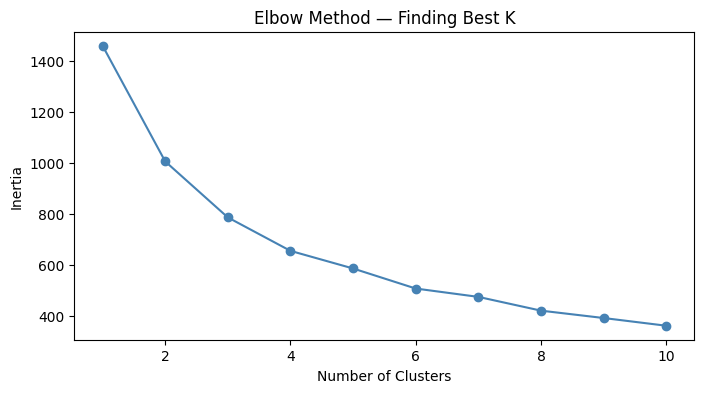

In [78]:
# Find best number of clusters using elbow method
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inertia, marker='o', color='steelblue')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Best K')
plt.show()

In [79]:
# Check silhouette score for each k
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"k={k} -> Silhouette Score: {round(score, 3)}")

k=2 -> Silhouette Score: 0.296
k=3 -> Silhouette Score: 0.297
k=4 -> Silhouette Score: 0.316
k=5 -> Silhouette Score: 0.238
k=6 -> Silhouette Score: 0.247


In [80]:
# Train final K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_pca)

# Label clusters by GDP level
gdpp_mean = df.groupby('Cluster')['gdpp'].mean().sort_values()
label_map = {
    gdpp_mean.index[0]: 'Under-Developed',
    gdpp_mean.index[1]: 'Developing',
    gdpp_mean.index[2]: 'Developed'
}
df['Development'] = df['Cluster'].map(label_map)

print("Countries per cluster:")
print(df['Development'].value_counts())

Countries per cluster:
Development
Developing         84
Under-Developed    47
Developed          36
Name: count, dtype: int64


In [81]:
# Average values per cluster
print("Cluster averages:")
df.groupby('Development')[['child_mort', 'income', 'gdpp', 'life_expec']].mean().round(1)

Cluster averages:


,child_mort,income,gdpp,life_expec
Development,,,,
Developed,5.0,45672.2,42494.4,80.1
Developing,21.9,12305.6,6486.5,72.8
Under-Developed,93.0,3942.4,1922.4,59.2


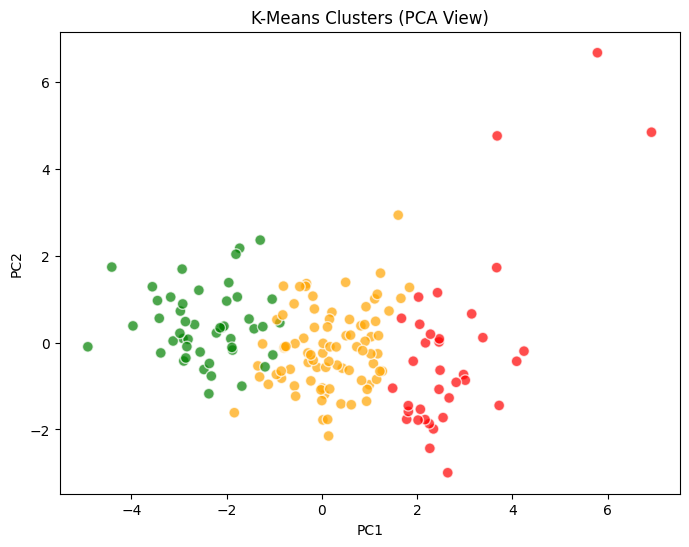

In [82]:
# Plot clusters in 2D
colors = df['Cluster'].map({0: 'red', 1: 'orange', 2: 'green'})

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, alpha=0.7, edgecolors='white', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters (PCA View)')
plt.show()

# 11) DBSCAN

In [83]:
# DBSCAN to find outlier countries
dbscan = DBSCAN(eps=1.3, min_samples=5)
df['DBSCAN'] = dbscan.fit_predict(X_pca)

n_clusters = len(set(df['DBSCAN'])) - (1 if -1 in df['DBSCAN'].values else 0)
n_noise = (df['DBSCAN'] == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Outlier countries: {n_noise}")
print("\nOutlier countries:")
print(df[df['DBSCAN'] == -1]['country'].values)

Clusters found: 1
Outlier countries: 36

Outlier countries:
['Angola' 'Belgium' 'Brunei' 'Central African Republic' 'Congo, Dem. Rep.'
 'Congo, Rep.' 'Equatorial Guinea' 'Gabon' 'Haiti' 'Ireland' 'Kiribati'
 'Kuwait' 'Lesotho' 'Liberia' 'Libya' 'Luxembourg' 'Malta'
 'Micronesia, Fed. Sts.' 'Moldova' 'Mongolia' 'Myanmar' 'Nigeria' 'Norway'
 'Oman' 'Qatar' 'Rwanda' 'Saudi Arabia' 'Seychelles' 'Sierra Leone'
 'Singapore' 'South Africa' 'Switzerland' 'Timor-Leste'
 'United Arab Emirates' 'United States' 'Venezuela']


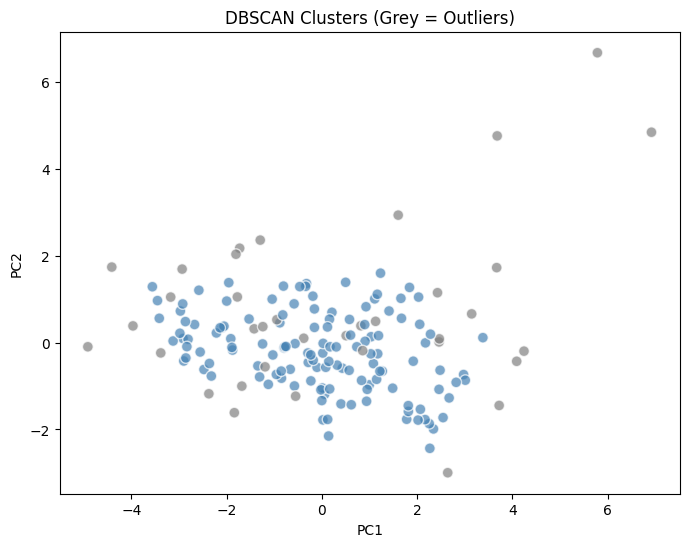

In [84]:
# Plot DBSCAN results
colors_db = ['grey' if l == -1 else 'steelblue' for l in df['DBSCAN']]

plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors_db, alpha=0.7, edgecolors='white', s=60)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Clusters (Grey = Outliers)')
plt.show()

# 12) Random Forest + XGBoost

In [85]:
# Use cluster labels as target
X_class = df.drop(['country', 'Cluster', 'Development', 'DBSCAN'], axis=1)
y = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X_class, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 133
Test size: 34


In [86]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print()
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9706

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      0.95      0.97        20
           2       0.86      1.00      0.92         6

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



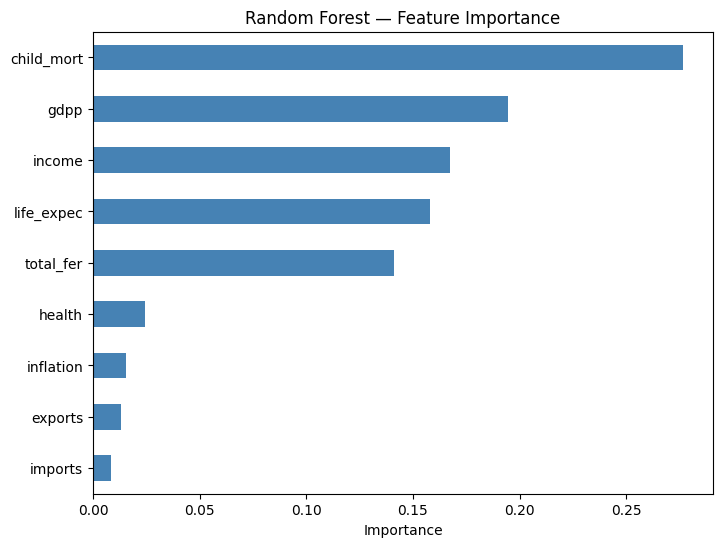

In [87]:
# Which features matter most?
importance = pd.Series(rf.feature_importances_, index=X_class.columns)
importance.sort_values().plot(kind='barh', figsize=(8, 6), color='steelblue')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Importance')
plt.show()

In [88]:
# Train XGBoost
xgb = XGBClassifier(n_estimators=100, random_state=42,
                     verbosity=0, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", round(accuracy_score(y_test, xgb_pred), 4))
print()
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.9706

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      0.95      0.97        20
           2       0.86      1.00      0.92         6

    accuracy                           0.97        34
   macro avg       0.95      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



Model Comparison:
Random Forest Accuracy : 0.9706
XGBoost Accuracy       : 0.9706


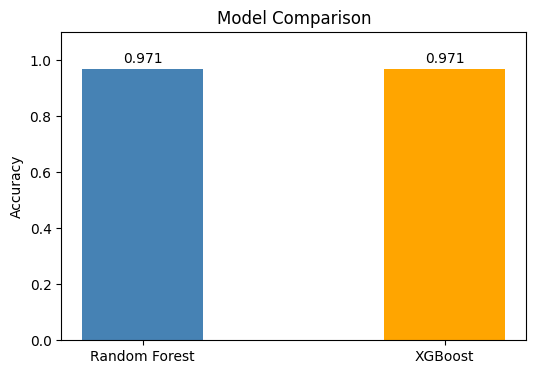

In [89]:
# Compare both models
print("Model Comparison:")
print(f"Random Forest Accuracy : {round(accuracy_score(y_test, rf_pred), 4)}")
print(f"XGBoost Accuracy       : {round(accuracy_score(y_test, xgb_pred), 4)}")

# Bar chart
models = ['Random Forest', 'XGBoost']
scores = [accuracy_score(y_test, rf_pred), accuracy_score(y_test, xgb_pred)]

plt.figure(figsize=(6, 4))
plt.bar(models, scores, color=['steelblue', 'orange'], width=0.4)
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
for i, v in enumerate(scores):
    plt.text(i, v + 0.02, str(round(v, 3)), ha='center')
plt.show()

# 13) Need Index (Which Countries Need Aid?)

In [90]:
# Score each country based on need for aid
need_cols = ['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer']

# Normalize to 0-1
scaled = MinMaxScaler().fit_transform(df[need_cols])
scaled = pd.DataFrame(scaled, columns=need_cols)

# Higher child_mort and total_fer = more need
# Lower income, gdpp, life_expec = more need
df['Need_Index'] = (
    0.30 * scaled['child_mort']
  - 0.25 * scaled['income']
  - 0.20 * scaled['gdpp']
  - 0.15 * scaled['life_expec']
  + 0.10 * scaled['total_fer']
)

# Top 15 countries needing aid
top15 = df.sort_values('Need_Index', ascending=False).head(15)
print("Top 15 countries needing aid:")
print(top15[['country', 'Need_Index']].to_string(index=False))

Top 15 countries needing aid:
                 country  Need_Index
                   Haiti    0.331771
Central African Republic    0.231331
                    Chad    0.224976
            Sierra Leone    0.224473
                    Mali    0.196963
                   Niger    0.196223
        Congo, Dem. Rep.    0.175299
                 Nigeria    0.162894
            Burkina Faso    0.161438
           Guinea-Bissau    0.152522
                  Angola    0.149260
              Mozambique    0.146026
           Cote d'Ivoire    0.145641
                  Guinea    0.142901
                 Burundi    0.137460


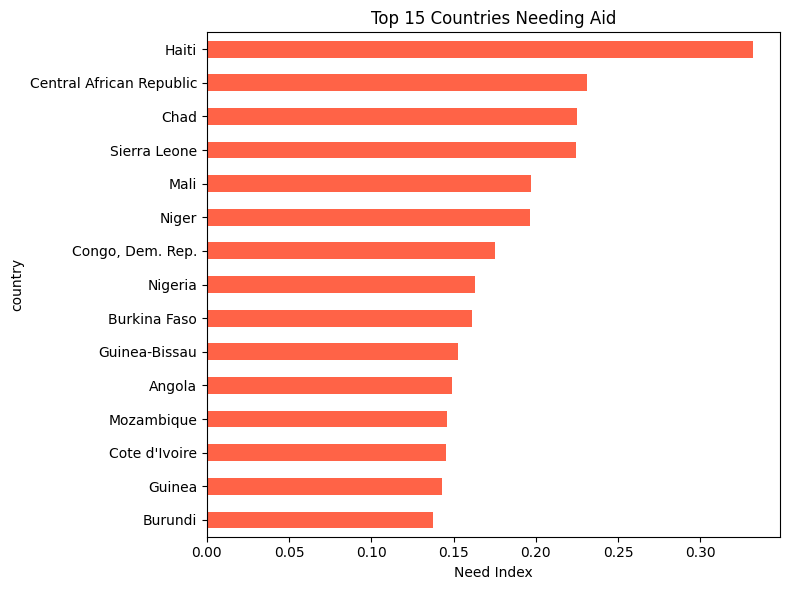

In [91]:
top15.sort_values('Need_Index').plot(
    kind='barh', x='country', y='Need_Index',
    figsize=(8, 6), color='tomato', legend=False)
plt.title('Top 15 Countries Needing Aid')
plt.xlabel('Need Index')
plt.tight_layout()
plt.show()

In [92]:
df.to_csv('Country_Output.csv', index=False)
print("File saved!")

File saved!


## 14) Final insights

Write 3 to 5 observations about the clusters:
- Which cluster has high child mortality?
- Which cluster has high income and gdpp?
- Which cluster looks underdeveloped?
- Which countries should be prioritized for aid?


### Final Insights and Observations

1. The Under-Developed cluster has the highest child mortality rate.
   - Average child mortality is approximately 100 deaths per 1000 live births, which is significantly higher than the other clusters.
   - This indicates poor healthcare facilities and lower living standards.

2. The Developed cluster has the highest income and GDP per capita.
   - Average income is around 45,662 and average GDP per capita is around 41,868.
   - These countries also have the highest life expectancy and better socio-economic conditions.

3. The Under-Developed cluster appears to be the most economically and socially disadvantaged group.
   - It has the lowest average income (2,815), lowest GDP per capita (1,361), and lowest life expectancy (58.7 years).
   - Therefore, this cluster can be classified as the most underdeveloped.

4. The Developing cluster represents countries in transition.
   - These countries show moderate income levels, moderate GDP, and better health indicators than underdeveloped nations but still lag behind developed countries.

5. Countries that should be prioritized for aid are those with the highest Need Index values.
   - Examples include Haiti, Central African Republic, Chad, Sierra Leone, Mali, and Niger.
   - These countries belong to the Under-Developed cluster and face severe socio-economic and health challenges.